In [ ]:
!pip install python-sat scikit-learn seaborn -q

### CNN aproach

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from pysat.solvers import Glucose3

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [ ]:
N_VARS      = 20
RATIOS      = [4.4]
N_SAMPLES   = 10000
BATCH_SIZE  = 128
EPOCHS      = 100
LR          = 3e-4

print(f'N_VARS    : {N_VARS}')
print(f'N_SAMPLES : {N_SAMPLES} per ratio')
print(f'Shape:')
for r in RATIOS:
    mc = int(r * N_VARS)
    print(f'  ratio={r}: {mc} x {N_VARS}  (fara padding)')

N_VARS    : 20
N_SAMPLES : 10000 per ratio
Shape:
  ratio=4.4: 88 x 20  (fara padding)


In [ ]:
def generate_3sat(n_vars, n_clauses):
    clauses = []
    for _ in range(n_clauses):
        vars_ = np.random.choice(n_vars, 3, replace=False) + 1
        lits  = [int(v) * (1 if np.random.rand() > 0.5 else -1) for v in vars_]
        clauses.append(lits)
    return clauses


def solve_sat(n_vars, clauses):
    solver = Glucose3()
    for clause in clauses:
        solver.add_clause(clause)
    result = solver.solve()
    solver.delete()
    return result


def formula_to_matrix(clauses, n_vars, max_clauses):
    matrix = np.zeros((max_clauses, n_vars), dtype=np.float32)
    for i, clause in enumerate(clauses[:max_clauses]):
        for lit in clause:
            var_idx = abs(lit) - 1
            matrix[i, var_idx] = 1.0 if lit > 0 else -1.0
    return matrix


def generate_balanced_dataset(n_vars, ratio, n_samples, max_clauses):
    n_clauses = int(ratio * n_vars)
    matrices, labels = [], []
    sat_count, unsat_count = 0, 0
    target = n_samples // 2
    print(f'Generare dataset: ratio={ratio}, n_vars={n_vars}, n_clauses={n_clauses}')
    while sat_count < target or unsat_count < target:
        clauses = generate_3sat(n_vars, n_clauses)
        is_sat  = solve_sat(n_vars, clauses)
        if is_sat and sat_count < target:
            matrices.append(formula_to_matrix(clauses, n_vars, max_clauses))
            labels.append(1.0)
            sat_count += 1
        elif not is_sat and unsat_count < target:
            matrices.append(formula_to_matrix(clauses, n_vars, max_clauses))
            labels.append(0.0)
            unsat_count += 1
        if (sat_count + unsat_count) % 5000 == 0 and (sat_count + unsat_count) > 0:
            print(f'  SAT: {sat_count}/{target}, UNSAT: {unsat_count}/{target}')
    print(f'Dataset done: {n_samples} exemple')
    return np.array(matrices), np.array(labels)


class SATDataset(Dataset):
    def __init__(self, matrices, labels):
        t = torch.tensor(matrices, dtype=torch.float32)
        self.X = t.permute(0, 2, 1)
        self.y = torch.tensor(labels, dtype=torch.float32)

    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

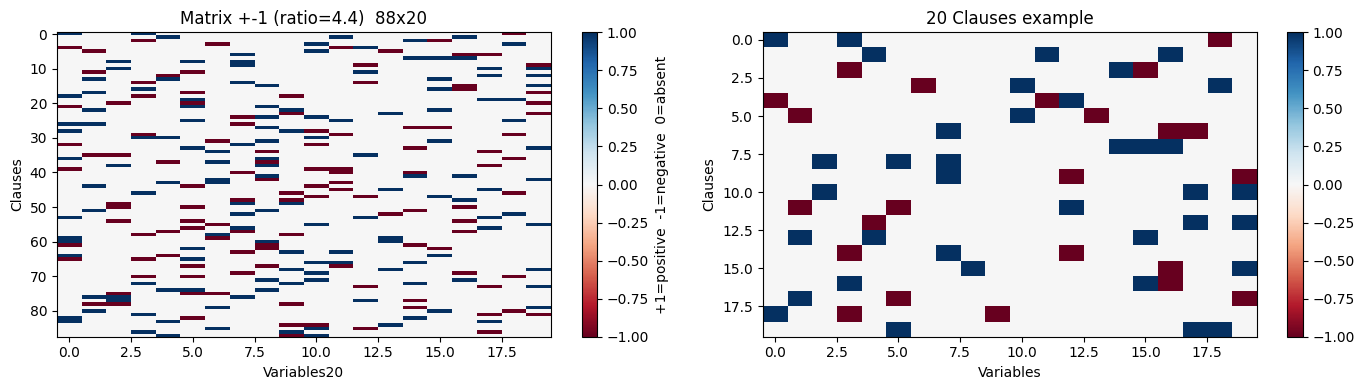

Shape: (88, 20)
Density : 264/1760 = 15.0% cells


In [ ]:
example_ratio   = 4.4
example_mc      = int(example_ratio * N_VARS)
example_clauses = generate_3sat(N_VARS, example_mc)
example_matrix  = formula_to_matrix(example_clauses, N_VARS, example_mc)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

im = axes[0].imshow(example_matrix, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
axes[0].set_title(f'Matrix +-1 (ratio={example_ratio})  {example_mc}x{N_VARS}', fontsize=12)
axes[0].set_xlabel(f'Variables{N_VARS}')
axes[0].set_ylabel('Clauses')
plt.colorbar(im, ax=axes[0], label='+1=positive  -1=negative  0=absent')

im2 = axes[1].imshow(example_matrix[:20], cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
axes[1].set_title('20 Clauses example', fontsize=12)
axes[1].set_xlabel('Variables')
axes[1].set_ylabel('Clauses')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

nonzero = int((example_matrix != 0).sum())
total   = example_matrix.size
print(f'Shape: {example_matrix.shape}')
print(f'Density : {nonzero}/{total} = {nonzero/total*100:.1f}% cells')

In [ ]:
class SATConvNet1D(nn.Module):
    def __init__(self, n_vars):
        super(SATConvNet1D, self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv1d(n_vars, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.3)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.3)
        )

        self.global_pool = nn.AdaptiveMaxPool1d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x.squeeze(1)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


model_test = SATConvNet1D(N_VARS)
x_test     = torch.randn(4, N_VARS, int(4.4 * N_VARS))
out_test   = model_test(x_test)
print(f'Input shape : {x_test.shape}')
print(f'Output shape: {out_test.shape}')
print(f'Trainable parameters: {count_parameters(model_test):,}')

Input shape : torch.Size([4, 20, 88])
Output shape: torch.Size([4])
Trainable parameters: 99,329


In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X)
        loss   = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        preds = (torch.sigmoid(logits) > 0.5).float()
        correct += (preds == y).sum().item()
        total   += len(y)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        logits = model(X)
        loss   = criterion(logits, y)
        total_loss += loss.item() * len(y)
        preds = (torch.sigmoid(logits) > 0.5).float()
        correct += (preds == y).sum().item()
        total   += len(y)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


def plot_results(history, ratio, preds, labels_true):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'3-SAT CNN 1D - Ratio {ratio}', fontsize=14, fontweight='bold')
    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_loss'],   label='Val')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
    axes[1].plot(history['train_acc'], label='Train')
    axes[1].plot(history['val_acc'],   label='Val')
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylim(0, 1); axes[1].legend()
    cm = confusion_matrix(labels_true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['UNSAT', 'SAT'],
                yticklabels=['UNSAT', 'SAT'], ax=axes[2])
    axes[2].set_title('Confusion Matrix')
    axes[2].set_ylabel('True'); axes[2].set_xlabel('Predicted')
    plt.tight_layout()
    plt.show()

In [ ]:
def train_and_evaluate(ratio):
    print('=' * 55)
    print(f'  RATIO: {ratio} clauses/variables')
    print('=' * 55)

    max_clauses = int(ratio * N_VARS)
    print(f'Matrix shape: {max_clauses} x {N_VARS} without padding')

    matrices, labels = generate_balanced_dataset(
        n_vars=N_VARS, ratio=ratio,
        n_samples=N_SAMPLES, max_clauses=max_clauses
    )
    dataset = SATDataset(matrices, labels)

    n_train = int(0.70 * len(dataset))
    n_val   = int(0.15 * len(dataset))
    n_test  = len(dataset) - n_train - n_val
    train_ds, val_ds, test_ds = random_split(
        dataset, [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

    model     = SATConvNet1D(N_VARS).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    print(f'Trainable parameters: {count_parameters(model):,}')

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc, best_state = 0, None

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc     = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, _, _   = eval_epoch(model, val_loader, criterion)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch {epoch:3d} | '
                  f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | '
                  f'Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}')

    model.load_state_dict(best_state)
    _, test_acc, preds, labels_true = eval_epoch(model, test_loader, criterion)

    print(f'Test Accuracy: {test_acc*100:.2f}%')
    print('Classification Report:')
    print(classification_report(labels_true, preds, target_names=['UNSAT', 'SAT']))

    plot_results(history, ratio, preds, labels_true)
    return test_acc, history

  RATIO: 4.4 clauses/variables
Matrix shape: 88 x 20 without padding
Generare dataset: ratio=4.4, n_vars=20, n_clauses=88
  SAT: 3055/5000, UNSAT: 1945/5000
  SAT: 5000/5000, UNSAT: 5000/5000
Dataset done: 10000 exemple
Trainable parameters: 99,329
Epoch   1 | Train Loss: 0.7164  Acc: 0.4994 | Val Loss: 0.6944  Acc: 0.4893
Epoch   5 | Train Loss: 0.6943  Acc: 0.4929 | Val Loss: 0.6939  Acc: 0.4853
Epoch  10 | Train Loss: 0.6927  Acc: 0.5143 | Val Loss: 0.6944  Acc: 0.4827
Epoch  15 | Train Loss: 0.6885  Acc: 0.5356 | Val Loss: 0.6937  Acc: 0.5107
Epoch  20 | Train Loss: 0.6854  Acc: 0.5484 | Val Loss: 0.6944  Acc: 0.5040
Epoch  25 | Train Loss: 0.6796  Acc: 0.5696 | Val Loss: 0.6960  Acc: 0.5013
Epoch  30 | Train Loss: 0.6753  Acc: 0.5836 | Val Loss: 0.6960  Acc: 0.4840
Epoch  35 | Train Loss: 0.6726  Acc: 0.5897 | Val Loss: 0.6970  Acc: 0.4853
Epoch  40 | Train Loss: 0.6712  Acc: 0.5897 | Val Loss: 0.6976  Acc: 0.4873
Epoch  45 | Train Loss: 0.6704  Acc: 0.5903 | Val Loss: 0.6981  Acc

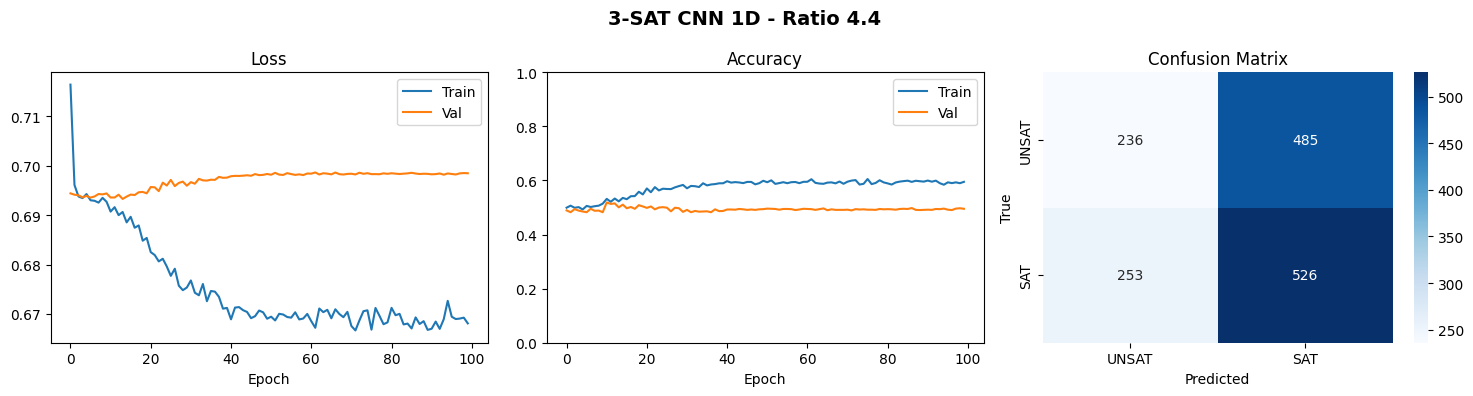

In [ ]:
all_results = {}

for ratio in RATIOS:
    test_acc, history = train_and_evaluate(ratio)
    all_results[ratio] = test_acc

### GNN

In [ ]:
!pip install python-sat scikit-learn seaborn -q
!pip install torch-geometric -q

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import add_self_loops
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from pysat.solvers import Glucose3
import random

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [ ]:
N_VARS    = 20
RATIOS    = [4.4]
N_SAMPLES = 10000

HIDDEN_DIM = 128
STATE_DIM  = 128
T_ITER     = 5

BATCH_SIZE  = 32
EPOCHS      = 100
LR          = 1e-4
GRAD_CLIP   = 1.0

print(f'N_VARS    : {N_VARS}')
print(f'N_SAMPLES : {N_SAMPLES}')
print(f'T_ITER    : {T_ITER}')
print(f'GRAD_CLIP : {GRAD_CLIP}')
for r in RATIOS:
    mc = int(r * N_VARS)
    print(f'  ratio={r}: {mc} clauses, edge features with shape {mc}')

N_VARS    : 20
N_SAMPLES : 10000
T_ITER    : 5
GRAD_CLIP : 1.0
  ratio=4.4: 88 clauses, edge features with shape 88


In [ ]:
def generate_3sat(n_vars, n_clauses):
    clauses = []
    for _ in range(n_clauses):
        vars_ = np.random.choice(n_vars, 3, replace=False) + 1
        lits  = [int(v) * (1 if np.random.rand() > 0.5 else -1) for v in vars_]
        clauses.append(lits)
    return clauses


def solve_sat(n_vars, clauses):
    solver = Glucose3()
    for clause in clauses:
        solver.add_clause(clause)
    result = solver.solve()
    solver.delete()
    return result


def formula_to_graph(clauses, n_vars):
    n_nodes   = 2 * n_vars
    n_clauses = len(clauses)

    x = torch.zeros(n_nodes, 2)
    for i in range(n_vars):
        x[2*i,   0] = 1.0
        x[2*i+1, 1] = 1.0

    edge_dict = {}

    for i in range(n_vars):
        u, v = 2*i, 2*i+1
        edge_dict[(u, v)] = np.zeros(n_clauses, dtype=np.float32)
        edge_dict[(v, u)] = np.zeros(n_clauses, dtype=np.float32)

    for clause_idx, clause in enumerate(clauses):
        nodes = []
        for lit in clause:
            var_idx = abs(lit) - 1
            nodes.append(2*var_idx if lit > 0 else 2*var_idx+1)

        for a in range(len(nodes)):
            for b in range(len(nodes)):
                if a != b:
                    u, v = nodes[a], nodes[b]
                    if (u, v) not in edge_dict:
                        edge_dict[(u, v)] = np.zeros(n_clauses, dtype=np.float32)
                    edge_dict[(u, v)][clause_idx] = 1.0

    edge_src = list([e[0] for e in edge_dict.keys()])
    edge_dst = list([e[1] for e in edge_dict.keys()])
    edge_attr = torch.tensor(np.array(list(edge_dict.values())), dtype=torch.float32)
    edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)


def generate_dataset(n_vars, ratio, n_samples):
    n_clauses = int(ratio * n_vars)
    graphs, labels = [], []
    sat_count, unsat_count = 0, 0
    target = n_samples // 2

    print(f'Generate dataset: ratio={ratio}, n_vars={n_vars}, n_clauses={n_clauses}')
    print(f'Edge features shape: {n_clauses}')

    while sat_count < target or unsat_count < target:
        clauses = generate_3sat(n_vars, n_clauses)
        is_sat  = solve_sat(n_vars, clauses)

        if is_sat and sat_count < target:
            g = formula_to_graph(clauses, n_vars)
            g.y = torch.tensor([1], dtype=torch.long)
            graphs.append(g)
            sat_count += 1
        elif not is_sat and unsat_count < target:
            g = formula_to_graph(clauses, n_vars)
            g.y = torch.tensor([0], dtype=torch.long)
            graphs.append(g)
            unsat_count += 1

        if (sat_count + unsat_count) % 1000 == 0 and (sat_count + unsat_count) > 0:
            print(f'  SAT: {sat_count}/{target}, UNSAT: {unsat_count}/{target}')

    random.shuffle(graphs)
    print(f'Generated dataset: {len(graphs)} graphs')
    return graphs


test_clauses = generate_3sat(5, int(4.4*5))
test_graph   = formula_to_graph(test_clauses, 5)
print(f'Nodes: {test_graph.num_nodes}')
print(f'Edges: {test_graph.num_edges}')
print(f'Node features shape: {test_graph.x.shape}')
print(f'Edge features shape: {test_graph.edge_attr.shape}')

Nodes: 10
Edges: 78
Node features shape: torch.Size([10, 2])
Edge features shape: torch.Size([78, 22])


In [ ]:
class TransitionFNN(nn.Module):
    def __init__(self, node_dim, edge_dim, state_dim, hidden_dim):
        super().__init__()
        input_dim = node_dim + edge_dim + state_dim + node_dim
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, state_dim)
        )

    def forward(self, ln, ln_u, x_u, lu):
        inp = torch.cat([ln, ln_u, x_u, lu], dim=-1)
        return self.net(inp)


class OutputFNN(nn.Module):
    def __init__(self, node_dim, state_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + node_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x_n, ln):
        inp = torch.cat([x_n, ln], dim=-1)
        return self.net(inp)


class SATGNNPaper(nn.Module):
    def __init__(self, node_in_dim, edge_dim, state_dim, hidden_dim, T_iter):
        super().__init__()
        self.T_iter   = T_iter
        self.state_dim = state_dim

        self.node_embed = nn.Linear(node_in_dim, state_dim)

        self.hw = TransitionFNN(
            node_dim=state_dim,
            edge_dim=edge_dim,
            state_dim=state_dim,
            hidden_dim=hidden_dim
        )

        self.gw = OutputFNN(
            node_dim=state_dim,
            state_dim=state_dim,
            hidden_dim=hidden_dim
        )

        self.classifier = nn.Linear(1, 1)

    def forward(self, data):
        x, edge_index, edge_attr, batch = (
            data.x, data.edge_index, data.edge_attr, data.batch
        )

        ln = self.node_embed(x)

        xn = torch.zeros_like(ln)

        src, dst = edge_index

        for _ in range(self.T_iter):
            ln_dst  = ln[dst]
            ln_u    = edge_attr
            x_u     = xn[src]
            lu      = ln[src]

            msg = self.hw(ln_dst, ln_u, x_u, lu)

            xn_new = torch.zeros_like(xn)
            xn_new.scatter_add_(0, dst.unsqueeze(1).expand_as(msg), msg)
            xn = xn_new

        on = self.gw(xn, ln)

        n_graphs = batch.max().item() + 1
        graph_out = torch.zeros(n_graphs, 1, device=x.device)
        count = torch.zeros(n_graphs, 1, device=x.device)
        graph_out.scatter_add_(0, batch.unsqueeze(1), on)
        count.scatter_add_(0, batch.unsqueeze(1), torch.ones_like(on))
        graph_out = graph_out / count

        return graph_out.squeeze(1)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


n_clauses_test = int(4.4 * N_VARS)
model_test = SATGNNPaper(
    node_in_dim=2,
    edge_dim=n_clauses_test,
    state_dim=STATE_DIM,
    hidden_dim=HIDDEN_DIM,
    T_iter=T_ITER
)
print(f'Trainable parameters: {count_parameters(model_test):,}')

test_g = formula_to_graph(generate_3sat(N_VARS, n_clauses_test), N_VARS)
test_g.batch = torch.zeros(test_g.num_nodes, dtype=torch.long)
out = model_test(test_g)
print(f'Output shape: {out.shape}')

Trainable parameters: 126,979
Output shape: torch.Size([1])


In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(batch)
        y = batch.y.float()
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        optimizer.step()
        total_loss += loss.item() * len(y)
        preds = (torch.sigmoid(logits) > 0.5).float()
        correct += (preds == y).sum().item()
        total   += len(y)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    for batch in loader:
        batch = batch.to(DEVICE)
        logits = model(batch)
        y = batch.y.float()
        loss = criterion(logits, y)
        total_loss += loss.item() * len(y)
        preds = (torch.sigmoid(logits) > 0.5).float()
        correct += (preds == y).sum().item()
        total   += len(y)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


def plot_results(history, ratio, preds, labels_true):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'3-SAT GNN with Ratio {ratio}', fontsize=14, fontweight='bold')
    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_loss'],   label='Val')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
    axes[1].plot(history['train_acc'], label='Train')
    axes[1].plot(history['val_acc'],   label='Val')
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylim(0, 1); axes[1].legend()
    cm = confusion_matrix(labels_true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['UNSAT', 'SAT'],
                yticklabels=['UNSAT', 'SAT'], ax=axes[2])
    axes[2].set_title('Confusion Matrix')
    axes[2].set_ylabel('True'); axes[2].set_xlabel('Predicted')
    plt.tight_layout()
    plt.show()

In [ ]:
def train_and_evaluate(ratio):
    print('=' * 55)
    print(f'  RATIO: {ratio} clauze/variabile')
    print('=' * 55)

    n_clauses = int(ratio * N_VARS)

    graphs = generate_dataset(N_VARS, ratio, N_SAMPLES)

    n_train = int(0.70 * len(graphs))
    n_val   = int(0.15 * len(graphs))
    train_graphs = graphs[:n_train]
    val_graphs   = graphs[n_train:n_train+n_val]
    test_graphs  = graphs[n_train+n_val:]

    train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_graphs,   batch_size=BATCH_SIZE)
    test_loader  = DataLoader(test_graphs,  batch_size=BATCH_SIZE)

    model = SATGNNPaper(
        node_in_dim=2,
        edge_dim=n_clauses,
        state_dim=STATE_DIM,
        hidden_dim=HIDDEN_DIM,
        T_iter=T_ITER
    ).to(DEVICE)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    print(f'Trainable parameters: {count_parameters(model):,}')

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc, best_state = 0, None

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc     = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, _, _   = eval_epoch(model, val_loader, criterion)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch {epoch:3d} | '
                  f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | '
                  f'Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}')

    model.load_state_dict(best_state)
    _, test_acc, preds, labels_true = eval_epoch(model, test_loader, criterion)

    print(f'Test Accuracy: {test_acc*100:.2f}%')
    print(f'Paper target : 65-70%')
    print('Classification Report:')
    print(classification_report(labels_true, preds, target_names=['UNSAT', 'SAT']))

    plot_results(history, ratio, preds, labels_true)
    return test_acc, history, model

  RATIO: 4.4 clauze/variabile
Generate dataset: ratio=4.4, n_vars=20, n_clauses=88
Edge features shape: 88
  SAT: 600/5000, UNSAT: 400/5000
  SAT: 1186/5000, UNSAT: 814/5000
  SAT: 1800/5000, UNSAT: 1200/5000
  SAT: 2425/5000, UNSAT: 1575/5000
  SAT: 3047/5000, UNSAT: 1953/5000
  SAT: 3677/5000, UNSAT: 2323/5000
  SAT: 4315/5000, UNSAT: 2685/5000
  SAT: 4924/5000, UNSAT: 3076/5000
  SAT: 5000/5000, UNSAT: 4000/5000
  SAT: 5000/5000, UNSAT: 4000/5000
  SAT: 5000/5000, UNSAT: 4000/5000
  SAT: 5000/5000, UNSAT: 5000/5000
Generated dataset: 10000 graphs
Trainable parameters: 126,979
Epoch   1 | Train Loss: 0.6948  Acc: 0.4964 | Val Loss: 0.6943  Acc: 0.4940
Epoch   5 | Train Loss: 0.6932  Acc: 0.5053 | Val Loss: 0.6931  Acc: 0.4940
Epoch  10 | Train Loss: 0.6889  Acc: 0.5393 | Val Loss: 0.6853  Acc: 0.5793
Epoch  15 | Train Loss: 0.6719  Acc: 0.5804 | Val Loss: 0.6686  Acc: 0.5647
Epoch  20 | Train Loss: 0.6686  Acc: 0.5873 | Val Loss: 0.6656  Acc: 0.5813
Epoch  25 | Train Loss: 0.6594  Ac

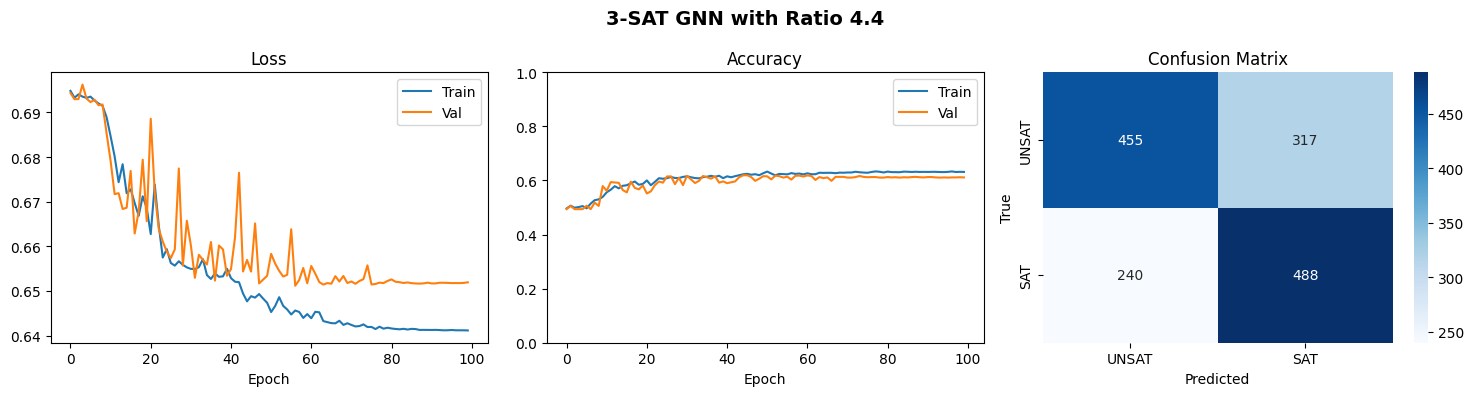

In [ ]:
all_results = {}
trained_models = {}

for ratio in RATIOS:
    test_acc, history, model = train_and_evaluate(ratio)
    all_results[ratio] = test_acc
    trained_models[ratio] = model